# Регрессионный анализ данных. Часть 1.
---
- Понятие регрессионного анализа. Построение регрессионной модели.
- Применение регрессионного анализа для решения образовательных задач: прогнозирование успеваемости, оценка эффективности обучения, выявление факторов успеха.
- Простая линейная регрессия. Построение линейной регрессии. Критерии оценки качества полученной модели.
- Построение множественной линейной регрессии.
- Регуляризация моделей. L1, L2 - регуляризация. Выбор коэффициента регуляризации.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=2)
plt.style.use('ggplot')

## **1. Понятие регрессионного анализа. Построение регрессионной модели.**
---

К задачам регрессионного анализа данных относятся задачи, в которых на основании ранее полученных данных наблюдения требуется исследовать/построить зависимости одних показателей от других. В этой теме мы рассмотрим задачи построения линейных регрессионных зависимостей.

---------

Мы предполагаем модель образования данных вида

$$y_i = f(x^{(i)}) + \varepsilon_i$$

Наша задача - восстановить неизвестную зависимость $f(x)$ по известным данным наблюдения - парам $(x^{(i)}, y_i), \; i=1,..,n$. Здесь $x^{(i)}$ - это векторное описание i-го объекта или значение предикторов для i-го объекта, $y_i$ - это значение целевого параметра для i-го объекта.


### ПРИМЕР 1.
---
- $y_i$ - это итоговый балл учащегося по дисциплине;
- $x^{(i)}$ - это вектор, описывающий параметры/характеристики i-го учащегося, например, его оценки по предыдущим дисциплинам или баллы за вступительные испытания, ....

### ПРИМЕР 2.
---
- $y_i$ - это вероятность того, что обучающийся сможет успешно завершить сессию;
- $x^{(i)}$ - это вектор, описывающий параметры/характеристики i-го учащегося, например, его оценки по предыдущим дисциплинам, баллы за вступительные испытания, ....

### ПРИМЕР 3.
---
- $y_i$ - количество абитуриентов, подавших заявления на поступление в ВУЗ;
- $x^{(i)}$ - это вектор, описывающий параметры/характеристики приемной кампании ВУЗа (сколько было потрачено денег на рекламу на ТВ, на радио, сколько проводилось дней открытых дверей, количество новых подписок в этом году на чат ВУЗа...).

Для решения этой задачи обычно используют критерий $L_2$-аппроксимации (критерий наименьших квадратов):

$(L_2) \; \Phi2 (\hat f) = \sum_{i=1..n}{(y_i - \hat f(x^{(i)}))^2} = \sum_{i=1..n}{\varepsilon_i^2} \to min$.

Данный критерий ошибки аппроксимации соответствует минимальному по длине вектору ошибки $\varepsilon$:

$$|\varepsilon|^2 = \sum_{i=1..n}{\varepsilon_i^2}$$

---------

Таким образом, мы можем сформулировать задачу аппроксимации следующим образом - "выбрать из некоторого множества возможных функций $K_f$ ту, которая лучше всего описывает данные с точки зрения выбранного критерия $\Phi2()$:"

$$ \hat f^* = arg\min_{\hat f \in K_f} \Phi2(\hat f)$$

----------


## **2. Пример задачи регрессионного анализа: прогнозирование успеваемости.**
---

В качестве примера рассмотрим реальную задачу прогноза итогового балла на онлайн-курсе по известным результатам выполнения заданий первой половины курса.

В практике онлайн-обучения есть несколько важных метрик оценки качества обучения. Одна из основных метрик - это процент удержания на курсе и процент завершения курса

- процент удержания на курсе (retention rate) - какой % студентов из начавших обучаться на курсе остались учиться на экваторе курса;
- процент завершения курса (completion rate) - какой % студентов из начавших обучаться на курсе завершили успешно курс;

Поэтому важно уметь прогнозировать итоговый балл студентов на курсе, чтобы понять преодолеют ли они порог успешного завершения курса.

Это оценку можно выполнить, если известны текущие их набранные баллы за работы на курсе. Обычно прогноз делаю на середине курса по полученным к этому времени результатам.

### **ЗАДАНИЕ 4.1.**
Допустим, что в условиях данного примера мы хотим на старте онлайн-курса прогнозировать процент удержания на курсе - какой % студентов из начавших обучаться на курсе продолжают учиться на экваторе курса?

Исходя из смысла задачи определите что может быть объектами наблюдения, формирующими размеченные данные - пары $(x^{(i)}, y_i), \; i=1,..,n$

Выберите верный с вашей точки зрения ответ.

### **ОТВЕТЫ:**

### **A.** $y_i$ -  баллы, которые i-й студент набирает к середине курса; $x^{(i)}$ - параметры/ характеристики i-го студента;
### **B.** $y_i$ -  количество студентов, которое проявляет активность в середине i-го запуска курса; $x^{(i)}$ - количество студентов, которое стартовало в i-м запуске курса;
### **C.** $y_i$ -  количество студентов, которое проявляет активность в середине i-го запуска курса; $x^{(i)}$ - средний балл, которые студенты получили на предварительном тестировании знаний при старте i-го запуска курса;
### **D.** $y_i$ -  процент студентов от количества стартовавших на курсе, которое проявляет активность в середине i-го запуска курса; $x^{(i)}$ - средний балл, которые студенты получили на предварительном тестировании знаний при старте i-го запуска курса;

-----

### Данные с онлайн-курса для обучения модели
---

Возьмем достаточно простой онлайн-курс "Академия онлайн-обучения-1 ступень" для преподавателей, который был открыт в 2019 году. Он состоял из 8 тем и в каждой теме был итоговый тест. Таким образом в качестве половины курса можно рассматривать завершение первых четырех тем/тестов.

Но, чтобы построить модель, нам необходмио также знать подсказки для модели - ответы, итоговые баллы обучающихся, которые мы хотим прогнозировать и на основе которых мы будет обучать модель. Это называется **размеченные данные**. Эти данные делят на две части: обучающую и тестовые выборки. На обучающей выборке (60-90 % размеченных данных) модель обучают, а на тестовых данных проверяют ее точность

Модель будем строить в таком виде:

$$y_M(x_1, x_2, x_3, x_4) = a_0 + a_1*x_1 + a_2*x_2 + a_3*x_3 + a_4*x_4.$$

Здесь $x_i$ - это баллы учащегося за тест i-й темы, $y$ - итоговый балл, $y_M$ - итоговый балл, предсказанный моделью.

Наша задача - подобрать коэффициенты $a_1, a_2, a_3, a_4$ так чтобы прогноз модели был "как можно ближе" к реальным суммарным баллам обучающихся:

$$ \Phi2({\bar a}) = \sum_{j=0}^{n}(y_j - y_M[j])^2 \to min;$$

или

$$ \Phi2({\bar a}) = \sum_{j=0}^{n}(y_j - (a_0 + a_1*x_1[j] + a_2*x_2[j] + a_3*x_3[j] + a_4*x_4[j]))^2 \to min.$$

Здесь $x_i[j]$ - это баллы $j$-го учащегося за тест i-й темы.

In [89]:
# подключаем наш диск
from google.colab import drive
drive.mount('/content/drive')

# Указываем путь к файлу с данными  !!!
dir_path = "/content/drive/My Drive/Colab Notebooks/teacher/COMP_MATH/Cases/case-4/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
# загрузим данные - результаты выполнения заданий на онлайн-курсе КПК "Академия онлайн-обучения"
course_file_name = "online_acad_lin"
csv_file_path = dir_path + course_file_name + ".csv"

data = pd.read_csv(csv_file_path, sep=';' )
data.tail(10)

,0,1,2,3,sum
888,10.00,9.63,8.44,10.0,45.93
889,0.00,0.00,0.00,0.0,0.00
890,8.81,9.63,8.02,10.0,61.53
891,6.86,9.04,9.17,10.0,68.31
892,10.00,10.00,9.75,10.0,76.19
893,0.00,0.00,0.00,0.0,0.00
894,8.52,9.72,8.33,10.0,53.89
895,8.52,9.04,9.33,10.0,54.11
896,7.33,6.93,0.00,10.0,57.45
897,0.00,10.00,10.00,0.0,20.00


In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       898 non-null    float64
 1   1       898 non-null    float64
 2   2       898 non-null    float64
 3   3       898 non-null    float64
 4   sum     898 non-null    float64
dtypes: float64(5)
memory usage: 35.2 KB


видим, что эти данные уже подготовлены, отсутствующие баллы заменены на 0.
Можно отфильтровать "нулевых" учащихся, которые не набрали ни одного балла и, скорее всего, просто не приступили к обучению.

In [92]:
data = data[data['sum'] > 0]
data.tail(10)

,0,1,2,3,sum
886,10.00,10.00,9.75,10.0,73.84
887,5.76,6.70,8.44,10.0,66.48
888,10.00,9.63,8.44,10.0,45.93
890,8.81,9.63,8.02,10.0,61.53
891,6.86,9.04,9.17,10.0,68.31
892,10.00,10.00,9.75,10.0,76.19
894,8.52,9.72,8.33,10.0,53.89
895,8.52,9.04,9.33,10.0,54.11
896,7.33,6.93,0.00,10.0,57.45
897,0.00,10.00,10.00,0.0,20.00


### **ЗАДАНИЕ 4.2.**
Для этих данных, укажите какой % обучающихся от всех записавшихся на курс, записались, но так и не приступили к обучению.

Выберите наиболее близкий ответ.

### **ОТВЕТЫ:**

### **A.** $18$%;
### **B.** $23$%;
### **C.** $28$%;
### **D.** $33$%;

-----

In [93]:
# первичный анализ данных
data.describe()

,0,1,2,3,sum
count,733.000000,733.000000,733.000000,733.000000,733.000000
mean,8.706235,8.514134,7.951501,7.958677,58.564816
std,1.699112,2.162328,2.443024,3.401687,18.450274
min,0.000000,0.000000,0.000000,0.000000,1.480000
25%,8.100000,8.110000,7.420000,8.130000,53.980000
50%,9.290000,9.260000,8.630000,9.630000,64.410000
75%,10.000000,10.000000,9.500000,10.000000,70.680000
max,10.000000,10.000000,10.000000,10.000000,80.000000


### **Подготовка данных для обучения модели**
--------

Для построения адекватной, непереобученной модели необходимо:
- выделить из массива данных матрицу значений предикторов X и значений выходной переменной в вектор Y;
- разделить исходную выборку на две части - обучающую и тестовую.

На обучающей выборке мы будем строить/обучать модель. На тестовой выборке  - проверять ее точность. Это позволит нам оценить и сравнить разные модели и выбрать лучшую.

In [69]:
# выделяем массив значений предиктивных переменных и выходной переменной
Xm = data.iloc[:,:-1]
Y = data.iloc[:,-1:]
Xm.shape, Y.shape

((733, 4), (733, 1))

In [70]:
from sklearn.model_selection import train_test_split

# Выделяем часть данных для обучения (70%), а часть - для проверки точности модели (30%)
x_train, x_test, y_train, y_test = train_test_split(Xm, Y, train_size=0.7, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((513, 4), (220, 4), (513, 1), (220, 1))

## **3. Построение простой линейной регрессии без дополнительных предикторов**
--------

Т.е. будем строить простую модель вида:

$$y_m(\bar x) = a_0 + a_1*x_1 + ...+ a_4*x_4$$


In [71]:
from sklearn.linear_model import LinearRegression

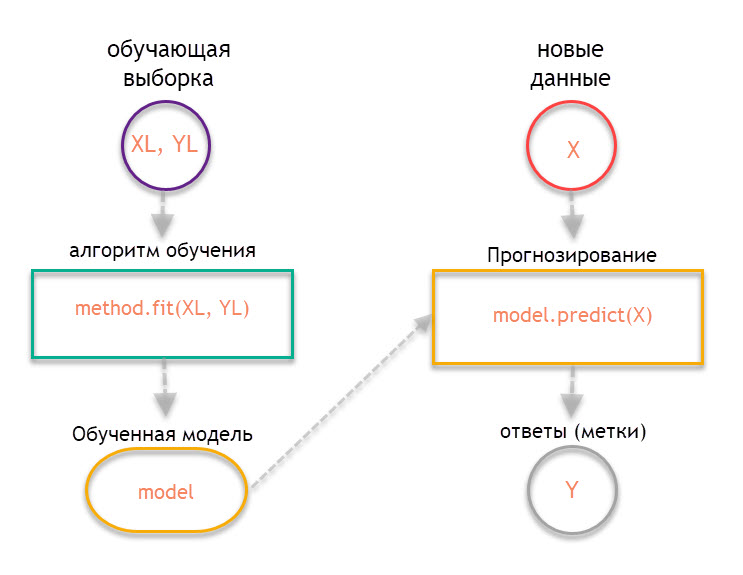

In [72]:
# создаем объект класса линейная регрессия
lin_reg = LinearRegression( )

# Обучаем модель на обучающей выборке
model = lin_reg.fit(x_train, y_train)

# выводим полученные коэффициент модели
print('a0=', model.intercept_)
print(model.coef_)

a0= [-4.02]
[[1.51 1.11 1.84 3.16]]


### Критерии оценки качества полученной модели.
---
Метрики оценки регрессионных моделей определяют качество прогнозирования числовых значений, измеряя разницу между предсказанными ($\hat y_j$) и фактическими данными ($y_j$).

Основные метрики — MAE (средняя абсолютная ошибка), MSE (среднеквадратичная ошибка), RMSE (корень из MSE) и \(R^{2}\) (коэффициент детерминации), где меньшие значения ошибок (MAE, MSE, RMSE) и \(R^{2}\) ближе к 1 указывают на более точную модель


Основные метрики регрессии

1. **MAE** (Mean Absolute Error) — Средняя абсолютная ошибка: Среднее арифметическое модулей отклонений предсказаний от факта.
> Особенность: Интерпретируема в тех же единицах, что и целевая переменная. Устойчива к выбросам. Формула:
$$MAE = \frac{1}{n} \sum_{j=1}^{n} |y_j - \hat{y}_j|$$

2. **MSE** (Mean Squared Error) — Среднеквадратичная ошибка: Среднее арифметическое квадратов разностей между фактом и прогнозом.
> Особенность: Сильно штрафует модель за большие ошибки (из-за возведения в квадрат). Формула:
$$MSE = \frac{1}{n} \sum_{j=1}^{n} (y_j - \hat{y}_j)^2$$

3. **RMSE** (Root Mean Squared Error) — Корень из MSE.
> Особенность: Также штрафует за большие ошибки, но, в отличие от MSE, измеряется в тех же единицах, что и целевая переменная.

4. $R^{2}$ (R-squared) — Коэффициент детерминации: Доля дисперсии целевой переменной, объясненная моделью.
> Особенность: Показывает качество модели относительно «наивного» прогноза (среднего значения). \(R^2 = 1\) — идеальная модель, \(R^2 < 0\) — модель хуже, чем просто среднее.

5. **MAPE** (Mean Absolute Percentage Error) — Средняя абсолютная процентная ошибка: Среднее процентное отклонение прогноза от факта.
> Особенность: Удобна для интерпретации качества в процентах, но не работает, если фактические значения равны 0.



Оценим полученную модель с помощью данных метрик. Модель оцениваем на тестовой выборке. Для этого надо рассчитать ее прогноз на тестовой выборке.

In [73]:
from sklearn import metrics

# расчет прогноза модели на тестовой выборке
y_predicted = model.predict(x_test)

# сравниваем прогноз и реальный суммарный балл с испльзованием метрик
print('MAE - Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_predicted))
print('MSE - Mean Squared Error:', metrics.mean_squared_error(y_test, y_predicted))
print('RMSE - Root Mean Squared Error:', metrics.root_mean_squared_error(y_test, y_predicted))
print('r2_score:', metrics.r2_score(y_test, y_predicted))
print('MAPE - Mean Absolute Percentage Error:', metrics.mean_absolute_percentage_error(y_test, y_predicted))

MAE - Mean Absolute Error: 5.712241455568111
MSE - Mean Squared Error: 53.646711786978166
RMSE - Root Mean Squared Error: 7.324391564285607
r2_score: 0.7878709059630407
MAPE - Mean Absolute Percentage Error: 0.10882031926037974


анализ показывает, что:
-  наша ошибка прогноза составляет примерно 10% (MAPE = 0.1);
- модель объясняет примерно 79 % разброса значений y. Это достаточно хорошое качество модели.

### **ЗАДАНИЕ 4.3.**
Пользуясь результатами расчета метрик, укахите насколько наш прогноз в среднем отклоняется от истинного значения суммарного балла.

Выберите наиболее близкий ответ.

### **ОТВЕТЫ:**

### **A.** $6$;
### **B.** $7$%;
### **C.** $0.8$%;
### **D.** $53$%;

-----

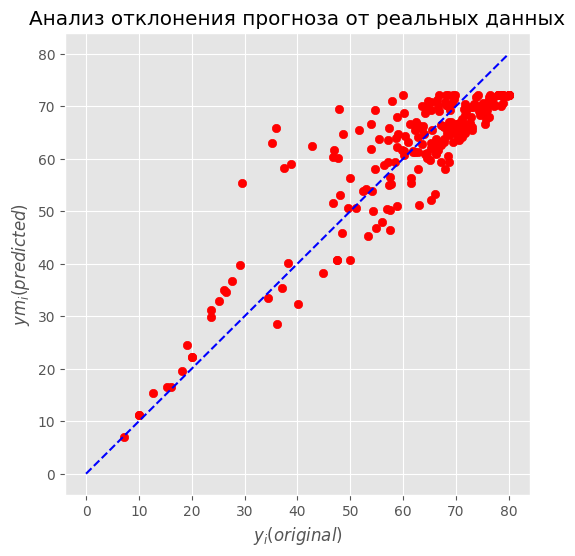

In [74]:
fig = plt.figure(figsize=(6, 6))
#plt.plot(_X, y_test, c='b', label='original')
plt.scatter(y_test, y_predicted, c='r', marker='o', label='predicted-original')
plt.xlabel('$y_i(original)$'); plt.ylabel('$ym_i(predicted)$')
plt.plot([0, 80], [0, 80], 'b--')
plt.title('Анализ отклонения прогноза от реальных данных');

## **4. Добавление в модель предикторов**
--------

Чтобы учесть нелинейные эффекты выполнения тестов добавим в модель слагаемые взаимодействия признаков/переменных:

$$y_m(\bar x) = a_0 + a_1*x_1 + ...+ a_4*x_4 + a_5*x_1*x_1 + a_6*x_1*x_2 + ..$$

In [108]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2) # указывать большую степень нет смысла

# добавляем предикторов в матрицы предикторов
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

x_train_poly.max()

np.float64(100.0)

In [109]:
# нормируем значения X_i, чтобы они все были в одинаковом интервале значений
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, Normalizer, RobustScaler

# нормируем значения X
scaler = MinMaxScaler()
x_train_poly = scaler.fit_transform(x_train_poly)

In [110]:
# создаем объект класса линейная регрессия
lin_reg = LinearRegression( )

# Обучаем модель на обучающей выборке
model_poly = lin_reg.fit(x_train_poly, y_train)

# выводим полученные коэффициент модели
print('a0=', model_poly.intercept_)
print(model_poly.coef_)

a0= [-1.58]
[[  0.    16.24  15.55  10.75  38.62  -5.5    7.67  -3.28   6.06 -12.92
    8.99  11.61   2.61   1.65 -23.9 ]]


In [111]:
x_test_poly = scaler.transform(x_test_poly)

# расчет прогноза модели на тестовой выборке
y_pred = model_poly.predict(x_test_poly)

# сравниваем прогноз и реальный суммарный балл с испльзованием метрик
print('MAE - Mean Absolute Error:', round(metrics.mean_absolute_error(y_test, y_pred), 2))
print('r2_score:', round(metrics.r2_score(y_test, y_pred), 5))
print('MAPE - Mean Absolute Percentage Error:', round(metrics.mean_absolute_percentage_error(y_test, y_pred), 4))

MAE - Mean Absolute Error: 5.6
r2_score: 0.79246
MAPE - Mean Absolute Percentage Error: 0.1058


### **ЗАДАНИЕ 4.4**
Укажите выполнение какого тестового задания (T1, T2, T3 или T4) имеет самое большое значение (вес, вклад) для формирования итогового балла.

Выберите ответ.

### **ОТВЕТЫ:**

### **A.** $T1$;
### **B.** $T2$;
### **C.** $T3$;
### **D.** $T4$;

-----

## **5. L1, L2-регуляризация**
----

Если наша модель слишком сложна и может переобучиться на обучающей выборке, то имеет смысл применить регуляризацию - добавление требования более спокойной модели за счет уменьшения абсолютных значений параметров модели.


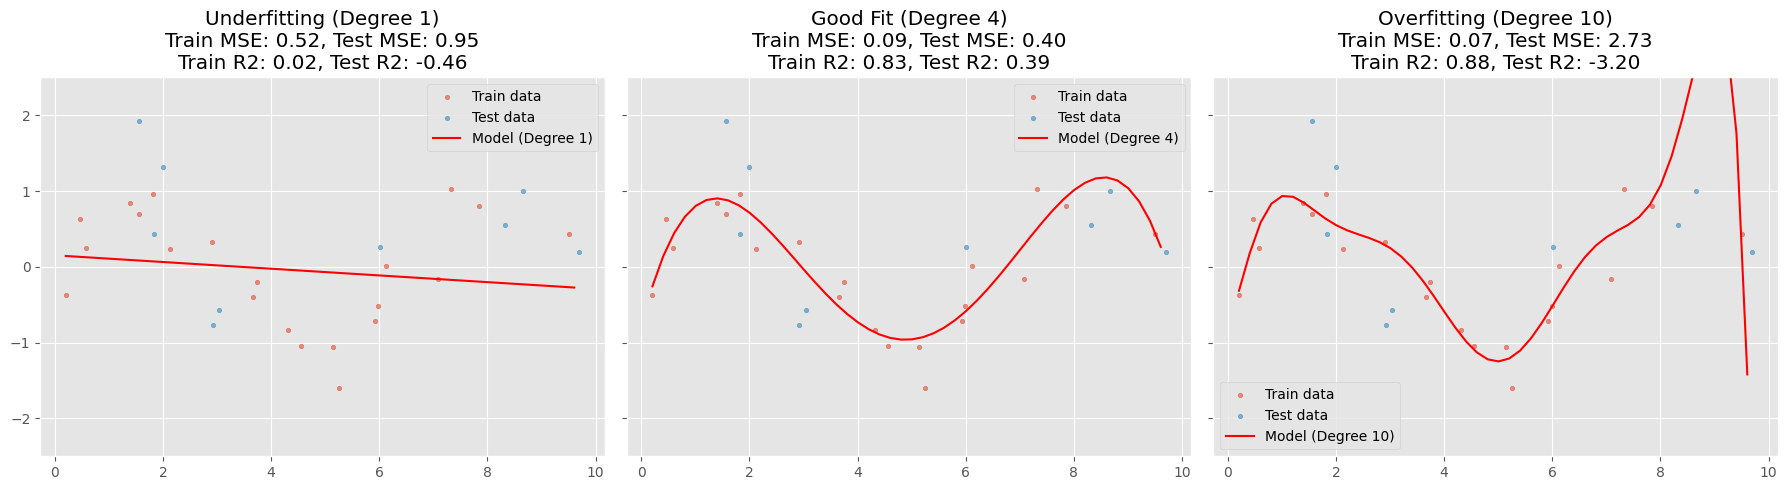

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate synthetic data
np.random.seed(42)
X_synth = np.sort(np.random.rand(30) * 10).reshape(-1, 1)
y_synth = np.sin(X_synth).ravel() + np.random.normal(0, 0.5, size=X_synth.shape[0])

# 2. Split synthetic data into training and testing sets
X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size=0.3, random_state=123)

# Function to train and evaluate polynomial models
def plot_polynomial_regression(degree, X_train, y_train, X_test, y_test, ax, plot_title):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    lin_reg_model = LinearRegression()
    lin_reg_model.fit(X_train_poly, y_train)

    y_train_pred = lin_reg_model.predict(X_train_poly)
    y_test_pred = lin_reg_model.predict(X_test_poly)

    # Evaluate metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Plotting
    ax.scatter(X_train, y_train, s=10, label='Train data', alpha=0.6)
    ax.scatter(X_test, y_test, s=10, label='Test data', alpha=0.6)

    # Sort X_synth to plot the prediction line smoothly
    X_plot = np.arange(np.min(X_synth), np.max(X_synth) + 0.1, 0.2).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot_pred = lin_reg_model.predict(X_plot_poly)
    ax.plot(X_plot, y_plot_pred, color='red', label=f'Model (Degree {degree})')

    ax.set_title(f'{plot_title}\nTrain MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}\nTrain R2: {train_r2:.2f}, Test R2: {test_r2:.2f}')
    ax.legend()
    ax.set_ylim(-2.5, 2.5)

# 3. Train and visualize models with different degrees
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Underfitting model (degree 1)
plot_polynomial_regression(1, X_train_synth, y_train_synth, X_test_synth, y_test_synth, axes[0], 'Underfitting (Degree 1)')

# Good fit model (degree 4)
plot_polynomial_regression(4, X_train_synth, y_train_synth, X_test_synth, y_test_synth, axes[1], 'Good Fit (Degree 4)')

# Overfitting model (degree 10)
plot_polynomial_regression(10, X_train_synth, y_train_synth, X_test_synth, y_test_synth, axes[2], 'Overfitting (Degree 10)')

plt.tight_layout()
plt.show()

### **L2 - регуляризация или гребневая регрессия**

$$ \Phi2({\bar a}) = \sum_{j=0}^{n}(y_j - y_M[j])^2 + \alpha \sum_{i=1}^m {a_i^2} \to min;$$

$\alpha$ - коэффициент регуляризации.

Применим L2-регуляризацию для построения модели в нашем примере.

In [112]:
# L2 - регуляризация или гребневый метод
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1)
model2 = ridge_reg.fit(x_train_poly, y_train)
print('a0=', model2.intercept_)
print(model2.coef_)

# проанализируем насколько хорошо получилось
y_predicted = model2.predict(x_test_poly)

# сравниваем прогноз и реальный суммарный балл с испльзованием метрик
print('MAE - Mean Absolute Error:', round(metrics.mean_absolute_error(y_test, y_predicted), 2))
print('r2_score:', round(metrics.r2_score(y_test, y_predicted), 5))
print('MAPE - Mean Absolute Percentage Error:', round(metrics.mean_absolute_percentage_error(y_test, y_predicted), 4))

a0= [-1.18]
[  0.    15.04  15.44  12.44  34.84  -4.55   2.8    1.5    6.22  -7.86
   4.17  10.97   0.58   3.49 -21.25]
MAE - Mean Absolute Error: 5.61
r2_score: 0.79251
MAPE - Mean Absolute Percentage Error: 0.1055


L2- регуляризация в данном случае дала неболшой эффект прироста качества модели

### **L1-регуляризация или метод LASSO**

$$ \Phi2({\bar a}) = \sum_{j=0}^{n}(y_j - y_M[j])^2 + \alpha \sum_{i=1}^m {|a_i|} \to min;$$

$\alpha$ - коэффициент регуляризации.

Применим L2-регуляризацию для построения модели в нашем примере.

In [120]:
from sklearn.linear_model import Lasso

method = Lasso(alpha=0.1)
model3 = method.fit(x_train_poly, y_train)
print('a0=', model3.intercept_)
print(model3.coef_)

# проанализируем насколько хорошо
y_predicted = model3.predict(x_test_poly)

# сравниваем прогноз и реальный суммарный балл с испльзованием метрик
print('MAE - Mean Absolute Error:', round(metrics.mean_absolute_error(y_test, y_predicted), 2))
print('r2_score:', round(metrics.r2_score(y_test, y_predicted), 5))
print('MAPE - Mean Absolute Percentage Error:', round(metrics.mean_absolute_percentage_error(y_test, y_predicted), 4))

a0= [6.94]
[ 0.    1.14 11.95  4.58 28.67  0.29  0.   15.23  2.48  0.    0.41  0.98
  0.    0.    0.  ]
MAE - Mean Absolute Error: 5.74
r2_score: 0.78875
MAPE - Mean Absolute Percentage Error: 0.1102


Видим, что точность модели повысилась

### **ЗАДАНИЕ 4.5**
Подберите значение параметра $\alpha$, при котором метод Лассо дает модель с самым большим значением критерия $R^2$. Укажите его.

Выберите ответ.

### **ОТВЕТЫ:**

### **A.** $0.01$;
### **B.** $0.02$;
### **C.** $0.03$;
### **D.** $0.05$;

-----

In [83]:
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 1, 100) # Generate 100 alpha values from 10^-4 to 10^2

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a, max_iter=10000)
    ridge.fit(x_train_poly, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(x_train_poly, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

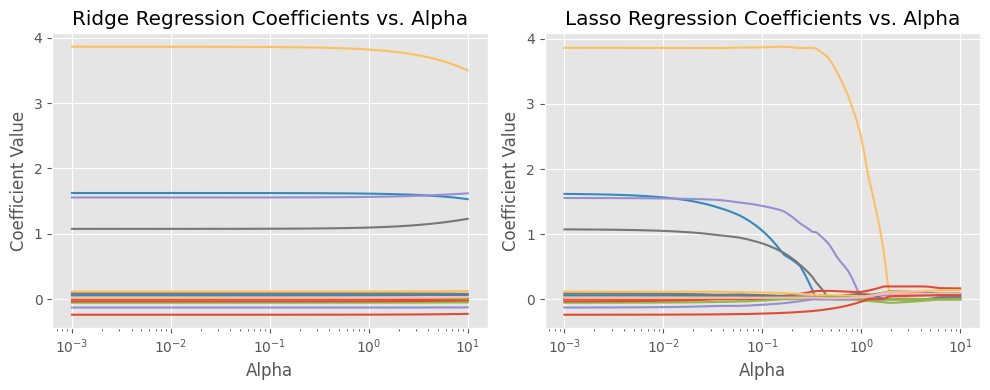

In [86]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Coefficients vs. Alpha')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression Coefficients vs. Alpha')
plt.grid(True)

plt.tight_layout()
plt.show()

## ВЫВОДЫ
---

- часто перед исследователем стоит задача оценить связь между параметрами процесса; понять как входные параметры процесса (обучения) влияют на итоговый результат; в этом случае применяют регрессионный анализ;

- регрессионный анализ - это процесс построения модели, функциональной зависимости выходнрой (зависимой) переменной от предикторов (входных переменных);

- после того, как мы определили вид модели (состав модели), осуществляется ее обучение - подгонка ее параметров под обучающую выборку;

- проверяют точность и качество модели всегда на дополнительной, тестовой выборке, на которой модель не обучалась;

- регуляризация помогает предотвратить переобучение модели - ее перенастройку на обучающую выборку.